In [5]:
import sys
from pathlib import Path

# Добавляем папку src (родительская директория для inference)
project_root = Path.cwd().parent
src_path = project_root / 'src'
sys.path.append(str(src_path))

print(f"Добавлен путь: {src_path}")
print(f"inference существует: {(src_path / 'inference').exists()}")

Добавлен путь: c:\Users\user\repos\coursework-idiomacy-ctg\src
inference существует: True


## Запуск судьи на случайных 10 примерах для 3х моделей

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path
from dotenv import load_dotenv
from inference.processor import CheckpointProcessor
from inference.model_constructor import FormatJudge

load_dotenv()

data = pd.read_csv(Path.cwd().parent / "data/dataset_maxi_literal.csv")

sample_texts = data["original_text_clean"].sample(n=10, random_state=42).tolist()
sample_indices = data["original_text_clean"].sample(n=10, random_state=42).index.tolist()

models = {
    "GigaChat-2": "gigachat",
    "GigaChat-2-Max": "gigachat",
    "GigaChat-2-Pro": "gigachat"
}

all_results = []

for model_name, provider in models.items():
    print(f"Запуск {model_name}")
    
    checkpoint_path = Path.cwd().parent / f"checkpoints/judge_{model_name}_checkpoint.csv"
    
    processor = CheckpointProcessor(
        model_name=model_name,
        provider=provider,
        prompt_name="judge_v1",
        structured_output_schema=FormatJudge,
        checkpoint_path=str(checkpoint_path),
        result_column_name="judge_scores",
        temperature=0.3
    )
    
    results = processor.process(
        df=pd.DataFrame({'text': sample_texts}),
        columns_mapping={'text': 'text'}
    )
    
    results['model'] = model_name
    results['original_index'] = sample_indices
    results['original_text'] = sample_texts
    
    all_results.append(results)

judge_comparison = pd.concat(all_results, ignore_index=True)
judge_comparison.to_csv(Path.cwd().parent / "judge_model_comparison.csv", index=False)

Запуск GigaChat-2


100%|██████████| 10/10 [00:05<00:00,  1.92it/s]


Запуск GigaChat-2-Max


100%|██████████| 10/10 [00:26<00:00,  2.68s/it]


Запуск GigaChat-2-Pro


100%|██████████| 10/10 [00:34<00:00,  3.43s/it]


In [16]:
import pandas as pd
from pathlib import Path

judge_comparison = pd.read_csv(Path.cwd().parent / "judge_model_comparison.csv")

def unpack_judge_result(row):
    """Распаковывает judge_scores из строки в отдельные колонки"""
    scores = row['judge_scores']
    
    if pd.isna(scores):
        return pd.Series({
            'grammar': None,
            'fluency': None,
            'naturalness': None,
            'idiomaticity': None,
            'idiomatic_expressions': []
        })
    
    # Парсим строку вида "grammar=5 fluency=4 naturalness=3 idiomaticity=1 idiomatic_expressions=[]"
    import re
    grammar_match = re.search(r'grammar=(\d+)', str(scores))
    fluency_match = re.search(r'fluency=(\d+)', str(scores))
    naturalness_match = re.search(r'naturalness=(\d+)', str(scores))
    idiomaticity_match = re.search(r'idiomaticity=(\d+)', str(scores))
    expressions_match = re.search(r'idiomatic_expressions=(\[.*?\])', str(scores))
    
    return pd.Series({
        'grammar': int(grammar_match.group(1)) if grammar_match else None,
        'fluency': int(fluency_match.group(1)) if fluency_match else None,
        'naturalness': int(naturalness_match.group(1)) if naturalness_match else None,
        'idiomaticity': int(idiomaticity_match.group(1)) if idiomaticity_match else None,
        'idiomatic_expressions': eval(expressions_match.group(1)) if expressions_match else []
    })

# Применяем распаковку
unpacked = judge_comparison.apply(unpack_judge_result, axis=1)

# Объединяем с исходным датафреймом
judge_comparison_clean = pd.concat([
    judge_comparison[['model', 'original_index', 'original_text']],
    unpacked
], axis=1)

# Сохраняем
judge_comparison_clean.to_csv(Path.cwd().parent / "judge_model_comparison_clean.csv", index=False)

print(judge_comparison_clean.head())

        model  original_index  \
0  GigaChat-2              73   
1  GigaChat-2               0   
2  GigaChat-2              58   
3  GigaChat-2              22   
4  GigaChat-2              12   

                                       original_text  grammar  fluency  \
0  Диагностика редких заболеваний может занимать ...        5        4   
1  Над пустыми петербургскими улицами пролетали е...        5        4   
2  Исторические локации и новые проекты\nКомпания...        5        4   
3  На семи холмах лежит городок Федор-Кузьмичск, ...        4        3   
4  Приказания прокуратора были исполнены быстро и...        5        4   

   naturalness  idiomaticity idiomatic_expressions  
0            3             1                    []  
1            3             1                    []  
2            3             1                    []  
3            3             1                    []  
4            3             1                    []  


## Расчёт статистики по идиомам

In [18]:
judge_comparison = pd.read_csv(Path.cwd().parent / "judge_model_comparison_clean.csv")

def count_idiom_words(idiom_list_str):
    if pd.isna(idiom_list_str):
        return 0
    try:
        if isinstance(idiom_list_str, str):
            idioms = eval(idiom_list_str)
        else:
            idioms = idiom_list_str
        total_words = sum(len(idiom.split()) for idiom in idioms)
        return total_words
    except:
        return 0

def count_text_words(text):
    return len(str(text).split())

judge_comparison['idiom_word_count'] = judge_comparison['idiomatic_expressions'].apply(count_idiom_words)
judge_comparison['text_word_count'] = judge_comparison['original_text'].apply(count_text_words)
judge_comparison['idiom_word_ratio'] = judge_comparison['idiom_word_count'] / judge_comparison['text_word_count']

print("Статистика по каждой модели:")
print(judge_comparison.groupby('model')[['idiom_word_count', 'text_word_count', 'idiom_word_ratio']].mean())

judge_comparison.to_csv(Path.cwd().parent / "judge_comparison_with_ratio.csv", index=False)

Статистика по каждой модели:
                idiom_word_count  text_word_count  idiom_word_ratio
model                                                              
GigaChat-2                   2.4            286.5          0.008302
GigaChat-2-Max              23.6            286.5          0.081738
GigaChat-2-Pro              42.1            286.5          0.145413


## Мердж с исходным датафреймом и сравнение с человеческой оценкой

In [27]:
data = pd.read_csv(Path.cwd().parent / "data/dataset_maxi_literal.csv")
judge_comparison = pd.read_csv(Path.cwd().parent / "judge_comparison_with_ratio.csv")

merged = judge_comparison.merge(
    data[['original_text_clean', 'word_count', 'ratio']], 
    left_on='original_text', 
    right_on='original_text_clean',
    how='left'
)

def ratio_to_level(ratio):
    if ratio <= 0.119:
        return 0
    elif ratio <= 0.380:
        return 1
    else:
        return 2

merged['human_level_by_ratio'] = merged['ratio'].apply(ratio_to_level)
merged['auto_level_by_ratio'] = merged['idiom_word_ratio'].apply(ratio_to_level)

print("Корреляция с человеческими метками")
print("\n1. По уровню (0/1/2) на основе ratio:")
for model in merged['model'].unique():
    subset = merged[merged['model'] == model]
    corr = subset['human_level_by_ratio'].corr(subset['auto_level_by_ratio'])
    print(f"  {model}: {corr:.4f}")

print("\n2. По непрерывному ratio:")
for model in merged['model'].unique():
    subset = merged[merged['model'] == model]
    corr = subset['ratio'].corr(subset['idiom_word_ratio'])
    print(f"  {model}: {corr:.4f}")

Корреляция с человеческими метками

1. По уровню (0/1/2) на основе ratio:
  GigaChat-2: nan
  GigaChat-2-Max: 0.6042
  GigaChat-2-Pro: 0.3932

2. По непрерывному ratio:
  GigaChat-2: -0.1417
  GigaChat-2-Max: 0.6932
  GigaChat-2-Pro: 0.6618


c:\Users\user\repos\coursework-idiomacy-ctg\venv\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\user\repos\coursework-idiomacy-ctg\venv\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


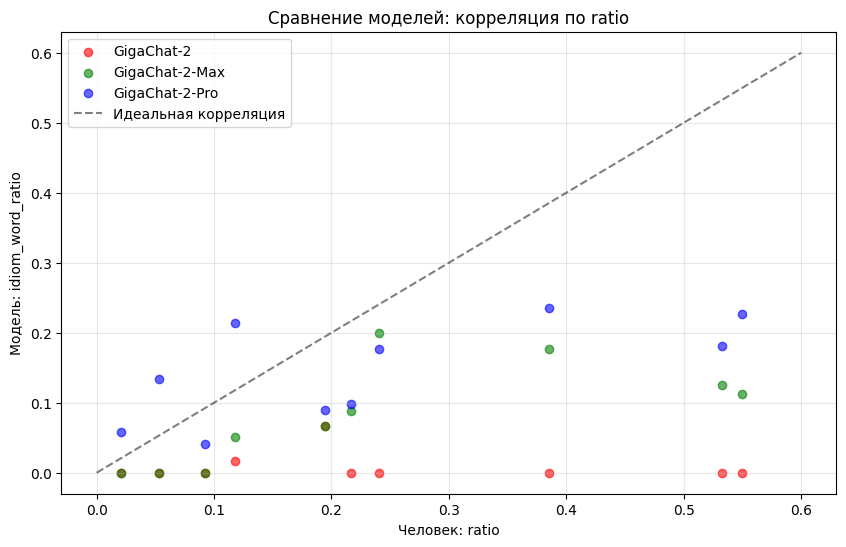

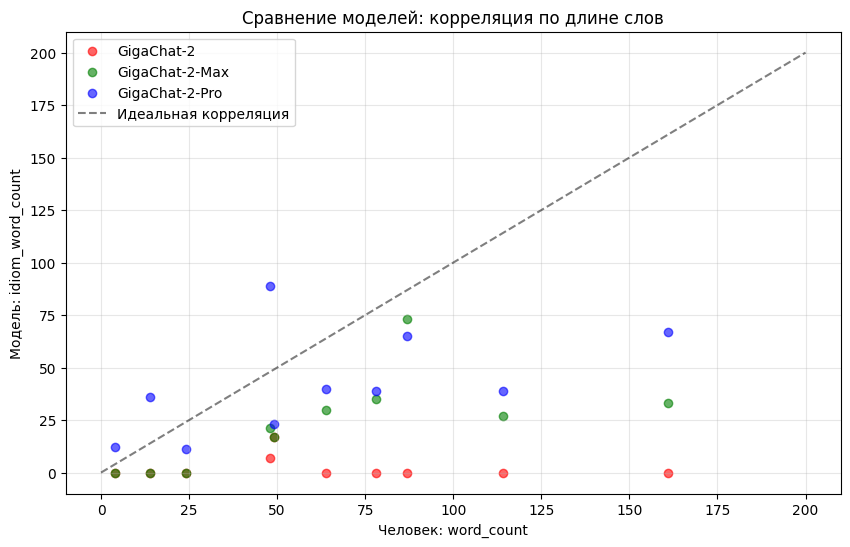

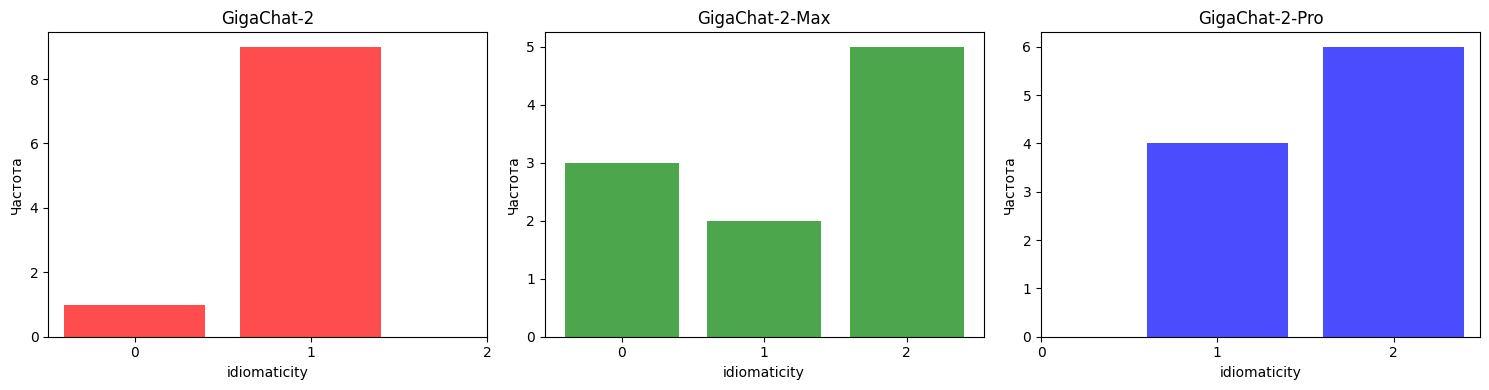

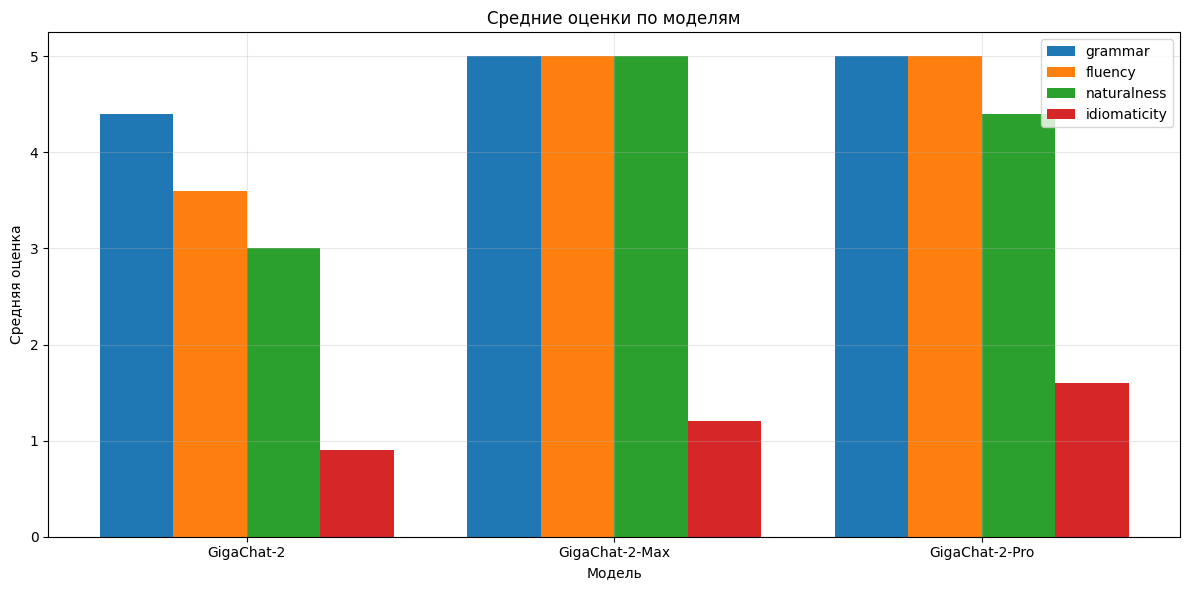

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Загрузка данных
judge_comparison = pd.read_csv(Path.cwd().parent / "judge_with_human_comparison.csv")

# Стиль графиков
plt.rcParams['figure.figsize'] = (10, 6)

models = ['GigaChat-2', 'GigaChat-2-Max', 'GigaChat-2-Pro']
colors = ['red', 'green', 'blue']

# График 1: Сравнение моделей по ratio
plt.figure(figsize=(10, 6))

for model, color in zip(models, colors):
    subset = judge_comparison[judge_comparison['model'] == model]
    plt.scatter(subset['ratio'], subset['idiom_word_ratio'], 
                alpha=0.6, label=model, color=color)

plt.plot([0, 0.6], [0, 0.6], 'k--', alpha=0.5, label='Идеальная корреляция')
plt.xlabel('Человек: ratio')
plt.ylabel('Модель: idiom_word_ratio')
plt.title('Сравнение моделей: корреляция по ratio')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# График 2: Сравнение моделей по длине слов
plt.figure(figsize=(10, 6))

for model, color in zip(models, colors):
    subset = judge_comparison[judge_comparison['model'] == model]
    plt.scatter(subset['word_count'], subset['idiom_word_count'], 
                alpha=0.6, label=model, color=color)

plt.plot([0, 200], [0, 200], 'k--', alpha=0.5, label='Идеальная корреляция')
plt.xlabel('Человек: word_count')
plt.ylabel('Модель: idiom_word_count')
plt.title('Сравнение моделей: корреляция по длине слов')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# График 3: Распределение idiomaticity (гистограммы)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model, color in zip(axes, models, colors):
    subset = judge_comparison[judge_comparison['model'] == model]
    counts = subset['idiomaticity'].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=color, alpha=0.7)
    ax.set_title(f'{model}')
    ax.set_xlabel('idiomaticity')
    ax.set_ylabel('Частота')
    ax.set_xticks([0, 1, 2])

plt.tight_layout()
plt.show()

# График 4: Средние значения метрик
avg_metrics = judge_comparison.groupby('model')[['grammar', 'fluency', 'naturalness', 'idiomaticity']].mean()

x = range(len(avg_metrics.index))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 6))

for i, metric in enumerate(['grammar', 'fluency', 'naturalness', 'idiomaticity']):
    ax.bar([pos + i*width for pos in x], avg_metrics[metric], width, label=metric)

ax.set_xlabel('Модель')
ax.set_ylabel('Средняя оценка')
ax.set_title('Средние оценки по моделям')
ax.set_xticks([pos + width*1.5 for pos in x])
ax.set_xticklabels(avg_metrics.index)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()